# **L1 и L2 регуляризация**

МНК позволяет найти оценку коэффициентов b уравнения 
$Y=Xb+E$
по формуле 
$b ̂=(X^T X)^{-1} X^T Y$.

При наличии мультиколлинеарности
1. Матрица $(X^T X)$. становится слабо обусловленной, т.е. ее определитель близок к нулю.
2. Решение b=(b0 b1...bр)T  становится неустойчивым.
3. Вектор b=(b0 b1...bр)T  содержит элементы, знаки которых не поддаются содержательной интерпретации.
4. Значимые коэффициенты bj могут оказаться статистически незначимыми, т.к. наблюдаемые значения t-статистики (коэффициент/стандартная ошибка)
оказываются заниженными (в результате гипотеза о равенстве коэффициента регрессии 0 не отвергается).

Подробнее см. стр. 20 «Эконометрика» В.С. Мхитарян, М.Ю. Архипова, В.П. Сиротин.

Способы борьбы с мультиколлинеарностью:
- Пошаговые алгоритм регрессионного анализа (метод пошагового включения / исключения переменных);
- методы снижения размерностей;
- Ридж и Лассо регрессия.

Ридж и Лассо позволяют ограничить или регуляризовать оценки коэффициентов и дисперсию оценок коэффициентов.

Лассо (L1), в отличие от Ридж-регрессии (L2), не только осуществляет регуляризацию, но и приравнивает некоторые из коэффициентов к нулю при достаточно большом значении λ. То есть Лассо дополнительно осуществляет выбор подмножества переменных, что позволяет легче интерпретировать модель.

В целом можно ожидать, что Лассо будет работать лучше в ситуациях, когда относительно небольшая группа предикторов имеет высокие коэффициенты, а коэффициенты остальных предикторов очень малы или близки к нулю.

Нахождение гиперпараметра λ (или alpha в python-документации sklearn) является критичным для Ридж и Лассо. Необходимо выбрать λ, которое приводило бы при небольшом смещении оценок к значительному снижению дисперсии оценок. Для нахождения λ используется метод перекрестной проверки (кросс-валидации). Исходная выборка разбивается на k блоков, в качестве обучающей выборки используется k-1 блок, оставшийся блок служит в качестве проверочного. Эта проверка повторяется k-раз: каждый раз в качестве проверочной выборки используется другой блок. В результате этого процесса получается k оценок ошибок на контрольной выборке – MSE1,…,MSEk. Итоговая оценка рассчитывается путем усреднения этих значений. Для различных λ рассчитываются итоговые оценки. Выбирается λ, соответствующая минимальной ошибке перекрестной проверки.

Подробнее см. стр. 235-250 «Введение в статистическое обучение с примерами на языке R» Джеймс Г., Уиттон Д., Хасти Т., Тибширани Р.

Итак, регуляризация может применяться для борьбы с мультиколлинеарностью, переобучением, отбора признаков.


In [1]:
# Ипортируем библиотеки
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import ShuffleSplit
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

import statsmodels.api as sm

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Изменим значение максимального количества отображаемых строк и столбцов
pd.options.display.max_columns = 20
pd.options.display.max_rows = 100
# Поменяем формат вывода чисел: разделим разряды запятой и будем выводить два знака после точки
pd.options.display.float_format = '{:,.2f}'.format

In [3]:
# Зададим параметры, которые будут использоваться в расчетах ниже
random_state=12345

## **Сбор данных**

In [4]:
%%time
# Загрузим датасет с GitHub
url = "https://raw.githubusercontent.com/eilicheva-art/datasets/refs/heads/main/russian_regions_stats_2024.csv"
df = pd.read_csv(url)

# Вычисляем границы выбросов и удаляем выбросы
Q1_y = df['y'].quantile(0.25)
Q3_y = df['y'].quantile(0.75)
IQR_y = Q3_y - Q1_y
upper_bound_critical_y = Q3_y + 3 * IQR_y
df = df[df['y'] <= upper_bound_critical_y].reset_index(drop=True)

# Выведем первые пять строк
df.head()

CPU times: total: 78.1 ms
Wall time: 1.49 s


,Регион,ФО,x1,x2,x3,x4,x5,x6,y
0,Белгородская область,ЦФО,56798,65.40,4.40,3.47,36.98,"26,875.30",6.10
1,Брянская область,ЦФО,48502,69.80,9.10,3.86,33.71,"23,953.70",6.50
2,Владимирская область,ЦФО,46302,77.59,7.40,2.31,33.49,"25,380.00",6.20
3,Воронежская область,ЦФО,53449,68.50,5.40,3.97,35.58,"23,816.50",6.90
4,Ивановская область,ЦФО,47881,82.20,8.00,2.69,32.49,"24,370.30",6.90


In [5]:
%%time
# Выведем количество строк в датасете
print("Количество наблюдений:", df.shape[0])

Количество наблюдений: 82
CPU times: total: 0 ns
Wall time: 288 μs


## **Корреляционный анализ**

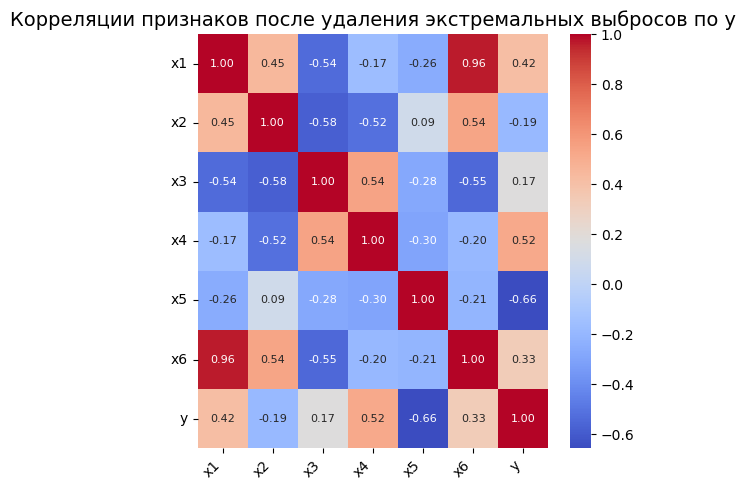

CPU times: total: 266 ms
Wall time: 262 ms


In [6]:
%%time
features = ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'y']
# Построим парные корреляции Пирсона между признаками на датасете после удаления экстремальных выбросов по y
plt.figure(figsize=(5, 5))
corr = df[features].corr()
sns.heatmap(
    corr,
    annot=True,              # показываем значения
    fmt='.2f',               # 2 знака после запятой
    cmap='coolwarm',         # цветовая схема
    annot_kws={'size': 8}    # размер шрифта аннотаций
)
plt.title('Корреляции признаков после удаления экстремальных выбросов по y', fontsize=14)
plt.xticks(rotation=45, ha='right')  # поворот подписей по X
plt.yticks(rotation=0)               # подписи по Y горизонтально
plt.tight_layout()
plt.show();

Между признаками `x1` и `x6` очень высокий коэффициент корреляции, значит есть проблема мультиколлинеарности.

In [7]:
# Оценим линейную ркгрессию на 10 бутстрапированных выборках
ss = ShuffleSplit(n_splits=10, test_size=0.25, random_state=random_state)
for train_index, test_index in ss.split(df):
    df_train = df.loc[train_index, features]
    df_test = df.loc[test_index, features]
    # Train
    features_df_train = df_train.drop('y', axis=1) # извлекаем признаки
    target_df_train = df_train['y'] # извлекаем целевой признак
    # Test
    features_df_test = df_test.drop('y', axis=1) # извлекаем признаки
    target_df_test = df_test['y'] # извлекаем целевой признак
    
    model = LinearRegression() # инициализируем модель LinearRegression
    model.fit(features_df_train, target_df_train) # оценка модели
    predictions_train = model.predict(features_df_train)
    mse_train = mean_squared_error(target_df_train, predictions_train)

    predictions_test = model.predict(features_df_test)
    mse_test = mean_squared_error(target_df_test, predictions_test)
    print(f'MSE модели на обучающей выборке {mse_train}, на тестовой выборке {mse_test}')
    print('Коэффициенты модели', model.coef_)
    print('Свобоный член', model.intercept_)

    # Оценим линейную регрессию из другой библиотеки для вывода большего количества статистик
    X = features_df_train
    y = target_df_train
    Xc = sm.add_constant(X) # Добавим константу
    model = sm.OLS(y,Xc) # инициализируем модель LinearRegression
    results = model.fit() # оценка модели
    print(results.summary())
    print('------------------------------------------------------------------------------------------------------------------------------')

MSE модели на обучающей выборке 0.8386863967517639, на тестовой выборке 0.8121662630968262
Коэффициенты модели [ 5.97308948e-05 -2.28974221e-02  3.61690434e-02  2.65641136e-01
 -1.34709587e-01 -1.08102250e-04]
Свобоный член 11.944358822784086
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.701
Model:                            OLS   Adj. R-squared:                  0.668
Method:                 Least Squares   F-statistic:                     21.08
Date:                Fri, 04 Sep 2026   Prob (F-statistic):           1.46e-12
Time:                        22:02:21   Log-Likelihood:                -81.190
No. Observations:                  61   AIC:                             176.4
Df Residuals:                      54   BIC:                             191.2
Df Model:                           6                                         
Covariance Type:            nonrobust         

Видим, что несмотря на то, что между коэффициентом `x1` и `x6` сильная прямая линейная связь, коэффициент `x1` значим и в регрессии имеет положительный знак, а коэффициент `x6` незначим и имеет отрицательный знак.

Также видим, что коэффициенты при `x2` и `x3` не значимы.

На некоторых подвыборках MSE на обучающей выборке значительно выше, чем на тестовой, что может быть сигналом переобучения.

In [8]:
# Подготовка данных для обучения
df = df[['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'y']]
df_train, df_test = train_test_split(df, test_size=0.25, random_state=random_state)
    
features_df_train = df_train.drop('y', axis=1) # извлекаем признаки
target_df_train = df_train['y'] # извлекаем целевой признак
    
features_df_test = df_test.drop('y', axis=1) # извлекаем признаки
target_df_test = df_test['y'] # извлекаем целевой признак

# Стандартизация признаков
scaler = StandardScaler() 
scaler.fit(features_df_train)
features_df_train = scaler.transform(features_df_train)
features_df_test = scaler.transform(features_df_test)                           

## **Лассо (L1)**

In [9]:
alphas = np.linspace(0, 1, 1000) # задаем массив значений гиперпараметра alpha для обучения Лассо
alphas_l = []
MSE_train_l = []
MSE_test_l = []
R2_train_l = []
R2_test_l = []
c_intercept = []
c_x1 = [] 
c_x2 = []
c_x3 = []
c_x4 = []
c_x5 = []
c_x6 = []

for a in alphas:
    model = Lasso(alpha=a)
    model.fit(features_df_train, target_df_train) # оценка модели
    predictions_train = model.predict(features_df_train)
    mse_train = mean_squared_error(target_df_train, predictions_train)
    R2_train = model.score(features_df_train, target_df_train)

    predictions_test = model.predict(features_df_test)
    mse_test = mean_squared_error(target_df_test, predictions_test)
    R2_test = model.score(features_df_test, target_df_test)
    alphas_l.append(a)
    MSE_train_l.append(mse_train)         
    MSE_test_l.append(mse_test)
    R2_train_l.append(R2_train)
    R2_test_l.append(R2_test)
    c_intercept.append(model.intercept_)
    c_x1.append(model.coef_[0])
    c_x2.append(model.coef_[1])
    c_x3.append(model.coef_[2])
    c_x4.append(model.coef_[3])
    c_x5.append(model.coef_[4])
    c_x6.append(model.coef_[5])
    # print(a)
    # print(f'MSE модели на обучающей выборке {mse_train}, на тестовой {mse_test}')
    # print(f'R2 модели на обучающей выборке {R2_train}, на тестовой {R2_test}')
    # print('Коэффициенты модели', model.coef_)
    # print('Свобоный член', model.intercept_)
    # print('------------------------------------------------------------------------------------------------------------------------------')

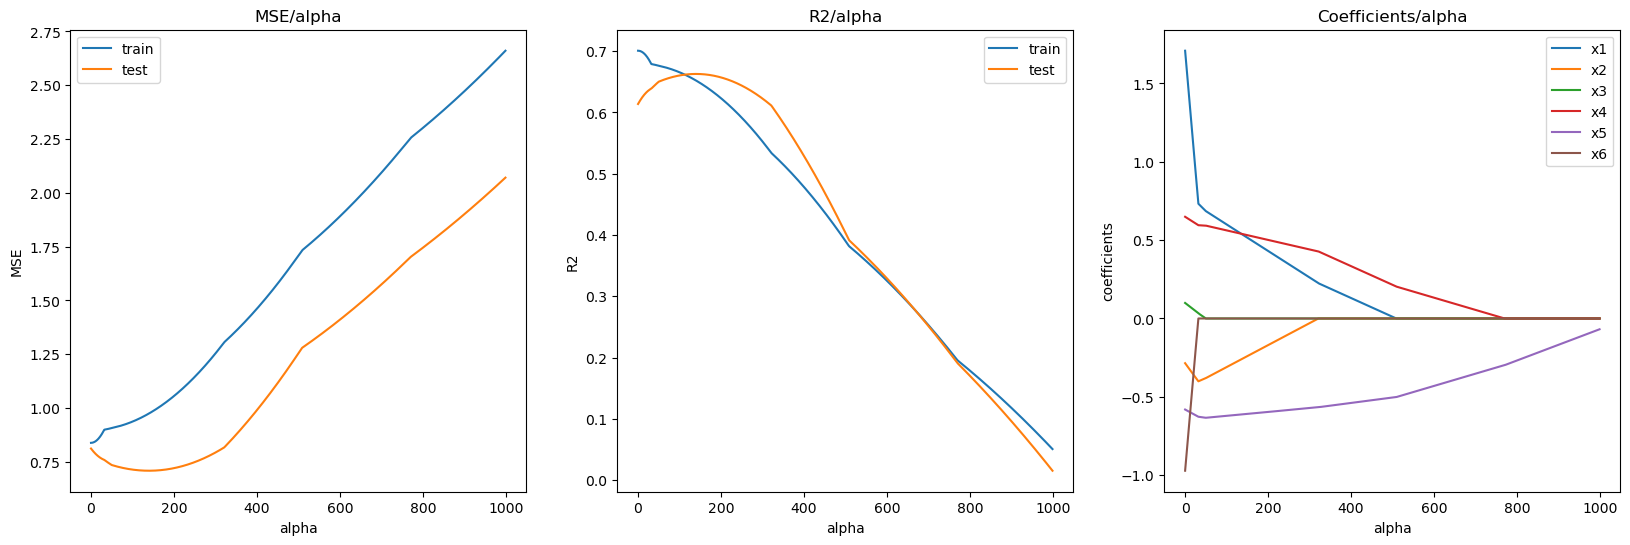

In [10]:
# Визуализируем результаты построения Лассо регрессии в зависимости от гиперпараметра alpha
plt.figure(figsize=(20, 6))
plt.subplot(1,3,1)
plt.plot(MSE_train_l, label = 'train')
plt.plot(MSE_test_l, label = 'test')
plt.legend(loc='best')
plt.xlabel('alpha')
plt.ylabel('MSE')
plt.title(f'MSE/alpha')

plt.subplot(1,3,2)
plt.plot(R2_train_l, label = 'train')
plt.plot(R2_test_l, label = 'test')
plt.legend(loc='best')
plt.xlabel('alpha')
plt.ylabel('R2')
plt.title(f'R2/alpha')

plt.subplot(1,3,3)
plt.plot(c_x1, label = 'x1')
plt.plot(c_x2, label = 'x2')
plt.plot(c_x3, label = 'x3')
plt.plot(c_x4, label = 'x4')
plt.plot(c_x5, label = 'x5')
plt.plot(c_x6, label = 'x6')
plt.legend(loc='best')
plt.xlabel('alpha')
plt.ylabel('coefficients')
plt.title(f'Coefficients/alpha')
plt.show()

In [11]:
alphas_l[np.argmin(MSE_test_l)]

np.float64(0.14014014014014015)

Видим, что при alpha равном примерно 0,14 достигается минимум MSE на тестовой выборке и максимальный R2 на тестовой выборке.

Также видим, что Лассо зануляет некоторые коэффициенты регрессии. Так, при alpha равном примерно 0,18 занулятся коэффициенты при x3 и x6.

Применение Лассо дает выигрыш по метрикам качества в сравнении с простой линейной регрессией.

In [12]:
model = Lasso(alpha=0.14014014014014015)
model.fit(features_df_train, target_df_train) # оценка модели
predictions_train = model.predict(features_df_train)
mse_train = mean_squared_error(target_df_train, predictions_train)
R2_train = model.score(features_df_train, target_df_train)

predictions_test = model.predict(features_df_test)
mse_test = mean_squared_error(target_df_test, predictions_test)
R2_test = model.score(features_df_test, target_df_test)

print(f'MSE модели на обучающей выборке {mse_train}, на тестовой {mse_test}')
print(f'R2 модели на обучающей выборке {R2_train}, на тестовой {R2_test}')
print('Коэффициенты модели', model.coef_)
print('Свобоный член', model.intercept_)

MSE модели на обучающей выборке 0.9752791057624207, на тестовой 0.7090826972848714
R2 модели на обучающей выборке 0.652056726091145, на тестовой 0.6628948605003899
Коэффициенты модели [ 0.53248577 -0.25419069  0.          0.53801418 -0.61130623  0.        ]
Свобоный член 8.188524590163935


## **Ридж (L2)**

In [13]:
alphas = np.linspace(0, 10, 1000) # задаем массив значений гиперпараметра alpha для обучения Ридж
alphas_l = []
MSE_train_l = []
MSE_test_l = []
R2_train_l = []
R2_test_l = []
c_intercept = []
c_x1 = [] 
c_x2 = []
c_x3 = []
c_x4 = []
c_x5 = []
c_x6 = []

for a in alphas:
    model = Ridge(alpha=a)
    model.fit(features_df_train, target_df_train) # оценка модели
    predictions_train = model.predict(features_df_train)
    mse_train = mean_squared_error(target_df_train, predictions_train)
    R2_train = model.score(features_df_train, target_df_train)

    predictions_test = model.predict(features_df_test)
    mse_test = mean_squared_error(target_df_test, predictions_test)
    R2_test = model.score(features_df_test, target_df_test)
    alphas_l.append(a)
    MSE_train_l.append(mse_train)         
    MSE_test_l.append(mse_test)
    R2_train_l.append(R2_train)
    R2_test_l.append(R2_test)
    c_intercept.append(model.intercept_)
    c_x1.append(model.coef_[0])
    c_x2.append(model.coef_[1])
    c_x3.append(model.coef_[2])
    c_x4.append(model.coef_[3])
    c_x5.append(model.coef_[4])
    c_x6.append(model.coef_[5])
    # print(a)
    # print(f'MSE модели на обучающей выборке {mse_train}, на тестовой {mse_test}')
    # print(f'R2 модели на обучающей выборке {R2_train}, на тестовой {R2_test}')
    # print('Коэффициенты модели', model.coef_)
    # print('Свобоный член', model.intercept_)
    # print('------------------------------------------------------------------------------------------------------------------------------')

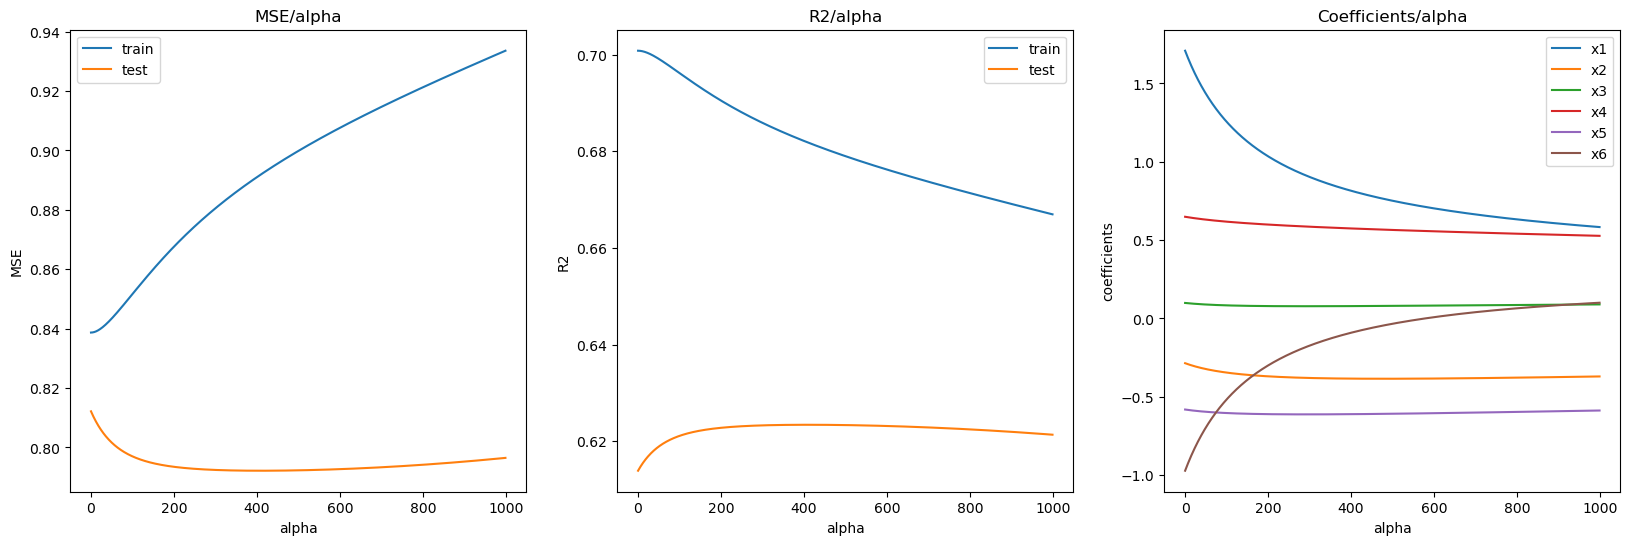

In [14]:
# Визуализируем результаты построения Ридж регрессии в зависимости от гиперпараметра alpha
plt.figure(figsize=(20, 6))
plt.subplot(1,3,1)
plt.plot(MSE_train_l, label = 'train')
plt.plot(MSE_test_l, label = 'test')
plt.legend(loc='best')
plt.xlabel('alpha')
plt.ylabel('MSE')
plt.title(f'MSE/alpha')

plt.subplot(1,3,2)
plt.plot(R2_train_l, label = 'train')
plt.plot(R2_test_l, label = 'test')
plt.legend(loc='best')
plt.xlabel('alpha')
plt.ylabel('R2')
plt.title(f'R2/alpha')

plt.subplot(1,3,3)
plt.plot(c_x1, label = 'x1')
plt.plot(c_x2, label = 'x2')
plt.plot(c_x3, label = 'x3')
plt.plot(c_x4, label = 'x4')
plt.plot(c_x5, label = 'x5')
plt.plot(c_x6, label = 'x6')
plt.legend(loc='best')
plt.xlabel('alpha')
plt.ylabel('coefficients')
plt.title(f'Coefficients/alpha')
plt.show()

In [15]:
alphas_l[np.argmin(MSE_test_l)]

np.float64(4.094094094094094)

Видим, что при alpha равном примерно 4 достигается минимум MSE на тестовой выборке и максимальный R2 на тестовой выборке.

Также видим, что Ридж ограничивает коэффициенты регрессии. Так коррелирующие коэффициенты x1 и x6 ограничиваются одновременно (не отдается предпочтение одному, как в Лассо).

Применение Ридж дает выигрыш по метрикам качества в сравнении с простой линейной регрессией.

In [16]:
model = Ridge(alpha=4.094094094094094)
model.fit(features_df_train, target_df_train) # оценка модели
predictions_train = model.predict(features_df_train)
mse_train = mean_squared_error(target_df_train, predictions_train)
R2_train = model.score(features_df_train, target_df_train)

predictions_test = model.predict(features_df_test)
mse_test = mean_squared_error(target_df_test, predictions_test)
R2_test = model.score(features_df_test, target_df_test)

print(f'MSE модели на обучающей выборке {mse_train}, на тестовой {mse_test}')
print(f'R2 модели на обучающей выборке {R2_train}, на тестовой {R2_test}')
print('Коэффициенты модели', model.coef_)
print('Свобоный член', model.intercept_)

MSE модели на обучающей выборке 0.8918611682718193, на тестовой 0.7921689585976485
R2 модели на обучающей выборке 0.681817140419425, на тестовой 0.6233948052634021
Коэффициенты модели [ 0.80856654 -0.38404032  0.0790919   0.57366192 -0.61053406 -0.08501269]
Свобоный член 8.188524590163935


## **Используемые материалы**

- [Лассо (L1)](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html)
- [Ридж (L2)](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html)